### 1. Import Libraries & Dependencies
**Cell Purpose:**
This cell imports all required Python libraries and modules needed for data manipulation, visualization, preprocessing, PyTorch neural network construction, data loading, and model evaluation metrics.

**Functions & Modules Explanation:**
- `numpy (np)`: Core library for high-performance multidimensional array operations and mathematical functions.
- `pandas (pd)`: Data analysis and manipulation library used for loading, cleaning, and processing tabular data.
- `matplotlib.pyplot (plt)` & `seaborn (sns)`: Visualization libraries used for rendering figures, distribution plots, and loss curves.
- `torch` & `torch.nn (nn)`: PyTorch deep learning framework and neural network module for constructing layers, loss functions, and activation functions.
- `TensorDataset` & `DataLoader`: PyTorch data utilities to wrap tensors into unified datasets and manage batching, shuffling, and multi-threaded iteration.
- `train_test_split`: Scikit-learn utility to perform stratified partitioning of datasets into train, validation, and test splits.
- `StandardScaler`: Scales numerical features to zero mean and unit variance ($Z = \frac{X - \mu}{\sigma}$).
- `OneHotEncoder`: Converts categorical string labels into dense binary one-hot vector representations.
- `ColumnTransformer`: Scikit-learn pipeline tool allowing different preprocessing pipelines to be applied to specified column subsets.
- `accuracy_score, precision_score, recall_score, f1_score, confusion_matrix`: Scikit-learn evaluation metrics to assess model performance.


In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

### 2. Load Raw Dataset
**Cell Purpose:**
Loads the Adult Income CSV dataset into a Pandas DataFrame, defines explicit column header names, and strips leading spaces after comma delimiters.

**Functions Used:**
- `pd.read_csv(...)`: Reads CSV file.
  - `header=None`: Indicates that the raw CSV file has no header row.
  - `names=column_names`: Assigns custom, descriptive column names.
  - `skipinitialspace=True`: Strips leading whitespace characters following commas in CSV records.


In [181]:
dataset = "../../Datasets/adult_income.csv"

column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(dataset, 
    header=None,
    names=column_names,
    skipinitialspace=True
)

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


### 3. Preview Dataset (Head & Tail)
**Cell Purpose:**
Displays the first 5 and last 5 rows of the DataFrame to inspect initial record formatting and structure.

**Functions Used:**
- `df.head()`: Returns the first 5 rows of the DataFrame.
- `df.tail()`: Returns the last 5 rows of the DataFrame.
- `print()`: Prints formatted text and DataFrame outputs.


In [182]:
print(df.head())
print()
print(df.tail())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

### 4. Dataset Shape & Dimensions
**Cell Purpose:**
Checks the total number of records (rows) and attributes (columns) present in the dataset.

**Attributes Used:**
- `df.shape`: Returns a tuple `(rows, columns)` representing total dataset dimensions (`32561, 15`).


In [183]:
df.shape

(32561, 15)

### 5. Dataset Information & Data Types
**Cell Purpose:**
Prints a summary of DataFrame metadata including memory usage, data types, and non-null entry counts per column.

**Functions Used:**
- `df.info()`: Summarizes column names, non-null value counts, and memory storage data types (`int64` for numericals, `str` for categoricals).


In [184]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


### 6. Check Standard Null Values
**Cell Purpose:**
Checks for standard missing values (`NaN`/`None`) across all columns in the DataFrame.

**Functions Used:**
- `df.isnull()`: Returns a boolean DataFrame where `True` indicates a missing value.
- `.sum()`: Sums boolean `True` values column-wise to count total nulls.


In [185]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

### 7. Identify Duplicate Rows
**Cell Purpose:**
Identifies duplicate records in the dataset to prevent data leakage and model bias.

**Functions Used:**
- `df.duplicated()`: Generates a boolean Series marking duplicate rows.
- `.sum()`: Calculates total count of duplicate rows (24 duplicate records found).


In [186]:
df.duplicated().sum()

np.int64(24)

### 8. Remove Duplicate Rows
**Cell Purpose:**
Removes identified duplicate rows from the dataset to ensure data cleanliness.

**Functions Used:**
- `df.drop_duplicates()`: Returns a new DataFrame with duplicate rows removed (reducing total rows from 32,561 to 32,537).


In [187]:
df = df.drop_duplicates()

print("\nClean dataset shape:", df.shape)


Clean dataset shape: (32537, 15)


### 9. Handle String Missing Values ('?') via Imputation
**Cell Purpose:**
In the Adult Income dataset, missing values are encoded as `'?'`. This cell replaces missing string values in categorical columns with `'Unknown'`.

**Functions Used:**
- `df[col].fillna('Unknown')`: Replaces null/missing entries in `workclass`, `occupation`, and `native-country` with `'Unknown'`, creating a distinct category for missing data during One-Hot Encoding.


In [188]:
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna('Unknown')

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


### 10. Separate Features (X) and Target (y)
**Cell Purpose:**
Isolates input feature matrix `X` from target series `y`, and maps target income categories (`<=50K` and `>50K`) into binary integers `0` and `1`.

**Functions Used:**
- `df.drop(["income"], axis=1)`: Removes the target column `income` from features `X`.
- `df["income"].map({"<=50K": 0, ">50K": 1})`: Maps binary target labels to `0` (`<=50K`) and `1` (`>50K`).
- `y.value_counts()` & `y.value_counts(normalize=True)`: Calculates raw counts and normalized class proportions (~75.9% `0` vs ~24.1% `1`).


In [189]:
X = df.drop(["income"], axis=1)

y = df["income"].map({"<=50K": 0, ">50K": 1})


print("\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))


Target distribution:
income
0    24698
1     7839
Name: count, dtype: int64
income
0    0.759074
1    0.240926
Name: proportion, dtype: float64


### 11. Stratified Train / Validation / Test Data Split
**Cell Purpose:**
Splits the dataset into 80% Training, 10% Validation, and 10% Testing sets using stratified sampling to preserve class balance across all splits.

**Functions Used:**
- `train_test_split(..., test_size=0.20, stratify=y)`: First split divides dataset into 80% train (26,029 samples) and 20% temporary set.
- `train_test_split(..., test_size=0.50, stratify=y_temp)`: Second split divides the 20% temporary set into equal 10% Validation (3,254 samples) and 10% Test (3,254 samples) sets.


In [190]:
# 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split temporary set equally:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nSplit sizes:")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))



Split sizes:
Train: 26029
Validation: 3254
Test: 3254


### 12. Identify Numerical & Categorical Columns
**Cell Purpose:**
Dynamically inspects training data column types to segregate feature names into numerical (`int64`) and categorical (`str`) lists.

**Functions Used:**
- `X_train.select_dtypes(include=['int64']).columns`: Extracts numerical feature names.
- `X_train.select_dtypes(include=['str']).columns`: Extracts categorical feature names.
- `.tolist()`: Converts Pandas Index objects to standard Python lists.


In [191]:
numerical_cols = X_train.select_dtypes(include=['int64']).columns

categorical_cols = X_train.select_dtypes(include=['str']).columns

print("\nNumerical:")
print(numerical_cols.tolist())

print("\nCategorical:")
print(categorical_cols.tolist())


Numerical:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


### 13. Preprocess Features via ColumnTransformer
**Cell Purpose:**
Constructs a scikit-learn `ColumnTransformer` to scale numerical features and one-hot encode categorical features, preventing data leakage by fitting exclusively on training data.

**Classes & Functions Used:**
- `StandardScaler()`: Standardizes numerical features to zero mean and unit variance.
- `OneHotEncoder(handle_unknown="ignore", sparse_output=False)`: Encodes categorical variables into a dense binary matrix, ignoring unseen categories during test inference.
- `ColumnTransformer(transformers=[...])`: Applies specified transformers to numerical and categorical feature subsets.
- `preprocessor.fit_transform(X_train)`: Fits scalers/encoders on `X_train` and transforms it into a 108-feature dense NumPy array.
- `preprocessor.transform(X_val)` & `preprocessor.transform(X_test)`: Transforms validation and test sets using pre-fitted parameters.


In [192]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            "numerical",
            StandardScaler(),
            numerical_cols
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols
        )
    ]
)


X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("\nAfter preprocessing:")
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)


After preprocessing:
Train: (26029, 108)
Validation: (3254, 108)
Test: (3254, 108)


### 14. Convert Arrays & Series to PyTorch Tensors
**Cell Purpose:**
Converts preprocessed feature arrays and target Series into PyTorch 32-bit FloatTensors formatted with 2D shapes.

**Functions & Methods Used:**
- `torch.tensor(array, dtype=torch.float32)`: Converts NumPy arrays to PyTorch FloatTensors.
- `y.to_numpy()`: Converts Pandas Series to 1D NumPy arrays.
- `.reshape(-1, 1)`: Reshapes 1D target arrays into 2D column matrices `(N, 1)` required by PyTorch loss functions.


In [193]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)

### 15. Create PyTorch TensorDatasets
**Cell Purpose:**
Pairs feature tensors and target tensors into PyTorch `TensorDataset` structures.

**Classes Used:**
- `TensorDataset(X_tensor, y_tensor)`: Combines input feature tensors and target label tensors into unified dataset objects.


In [194]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

### 16. Build PyTorch DataLoaders
**Cell Purpose:**
Wraps `TensorDataset` objects into `DataLoader` iterators to stream data in mini-batches of size 128 during model training and evaluation.

**Classes & Parameters Used:**
- `DataLoader(dataset, batch_size=128, shuffle=True/False)`: Manages mini-batch iteration. `batch_size=128` sets batch size; `shuffle=True` randomizes training samples every epoch; `shuffle=False` maintains fixed order for validation and testing.


In [195]:
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### 17. Configure Computation Device (CPU / GPU)
**Cell Purpose:**
Detects hardware capabilities and assigns the execution device (`cuda` GPU or `cpu`).

**Functions Used:**
- `torch.cuda.is_available()`: Checks if an NVIDIA CUDA-enabled GPU is available.
- `torch.device("cuda" if ... else "cpu")`: Instantiates PyTorch device object.


In [196]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)



Device: cpu


### 18. Define Artificial Neural Network (ANN) Architecture
**Cell Purpose:**
Defines a 3-layer fully connected feedforward Artificial Neural Network (`AdultANN`) in PyTorch.

**Classes & Layers Used:**
- `class AdultANN(nn.Module)`: Inherits from PyTorch `nn.Module` base class.
- `nn.Linear(in_features, out_features)`: Fully connected linear layer.
  - `fc1`: Maps 108 input features to 64 hidden neurons.
  - `fc2`: Maps 64 hidden neurons to 32 hidden neurons.
  - `fc3`: Maps 32 hidden neurons to 1 output logit.
- `nn.ReLU()`: Rectified Linear Unit activation function ($f(x) = \max(0, x)$) introducing non-linear transformations.
- `.to(device)`: Transfers network parameters to target CPU/GPU memory.


In [197]:
input_size = X_train_processed.shape[1]


class AdultANN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x


model = AdultANN(input_size).to(device)

print(model)

AdultANN(
  (fc1): Linear(in_features=108, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


### 19. Initialize Loss Function & Optimizer
**Cell Purpose:**
Configures Binary Cross-Entropy loss function (`BCEWithLogitsLoss`) and Adam optimizer (`lr=0.001`).

**Classes Used:**
- `nn.BCEWithLogitsLoss()`: Combines Sigmoid activation and Binary Cross Entropy loss in a single numerically stable function for binary classification.
- `torch.optim.Adam(model.parameters(), lr=0.001)`: Adaptive Moment Estimation optimizer that updates model weights based on first and second gradient moments.


In [198]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

### 20. Execute Training Loop with Validation & Early Stopping
**Cell Purpose:**
Trains the ANN over up to 50 epochs, tracks training and validation losses, applies Early Stopping (patience=5), and saves/restores the best model weights.

**Functions & Control Flow:**
- `model.train()`: Enables training mode (activates Dropout/BatchNorm updates).
- `optimizer.zero_grad()`: Clears accumulated gradients before each backward pass.
- `model(X_batch)`: Computes forward pass output logits.
- `criterion(logits, y_batch)`: Calculates BCE loss.
- `loss.backward()`: Computes gradients via backpropagation.
- `optimizer.step()`: Updates network parameters using Adam optimization.
- `model.eval()`: Switches model to evaluation mode (disables Dropout/BatchNorm).
- `with torch.no_grad()`: Context manager disabling autograd calculation during validation to accelerate inference and save memory.
- `{k: v.clone() for k, v in model.state_dict().items()}`: Clones model state dictionary to store the best weights when validation loss improves.
- `model.load_state_dict(best_model_state)`: Restores optimal weights after training completes or early stopping triggers.


In [199]:
EPOCHS = 50
patience = 5                                     # Stop if val_loss doesn't improve for 5 consecutive epochs

patience_counter = 0
best_val_loss = float('inf')
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()                                # Switch network to training mode

    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        # Move input features (X_batch) and target labels (y_batch) to computation device
        X_batch = X_batch.to(device)             
        y_batch = y_batch.to(device)             

        optimizer.zero_grad()                    # Clear gradients from previous batch          

        logits = model(X_batch)                  # Forward propagation

        loss = criterion(logits, y_batch)        # Loss calculation

        loss.backward()                          # Backpropagation

        optimizer.step()                         # Parameter update (Gradient descent update)

        total_train_loss += loss.item() * X_batch.size(0)

    avg_train_loss = (
        total_train_loss / len(train_loader.dataset)
    )




    model.eval()                                     # Set model to evaluation mode

    total_val_loss = 0

    with torch.no_grad():                            # Disable gradient tracking to save memory and speed up evaluation.

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(logits, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)

        avg_val_loss = (total_val_loss / len(val_loader.dataset))

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )


    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        print(f"Validation loss did not improve ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\n[Early Stopping Triggered] Stopped training at Epoch {epoch + 1}")
            break


# Load the best model weights back into the model for testing
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Successfully restored best model weights based on validation loss!")

Epoch 01/50 | Train Loss: 0.4039 | Val Loss: 0.3149
Epoch 02/50 | Train Loss: 0.3147 | Val Loss: 0.3073
Epoch 03/50 | Train Loss: 0.3092 | Val Loss: 0.3052
Epoch 04/50 | Train Loss: 0.3060 | Val Loss: 0.3065
Validation loss did not improve (1/5)
Epoch 05/50 | Train Loss: 0.3040 | Val Loss: 0.3053
Validation loss did not improve (2/5)
Epoch 06/50 | Train Loss: 0.3027 | Val Loss: 0.3037
Epoch 07/50 | Train Loss: 0.3008 | Val Loss: 0.3034
Epoch 08/50 | Train Loss: 0.2993 | Val Loss: 0.3046
Validation loss did not improve (1/5)
Epoch 09/50 | Train Loss: 0.2980 | Val Loss: 0.3058
Validation loss did not improve (2/5)
Epoch 10/50 | Train Loss: 0.2961 | Val Loss: 0.3071
Validation loss did not improve (3/5)
Epoch 11/50 | Train Loss: 0.2953 | Val Loss: 0.3066
Validation loss did not improve (4/5)
Epoch 12/50 | Train Loss: 0.2940 | Val Loss: 0.3064
Validation loss did not improve (5/5)

[Early Stopping Triggered] Stopped training at Epoch 12
Successfully restored best model weights based on val

### 21. Plot Training vs. Validation Loss Curves
**Cell Purpose:**
Renders line plots comparing training loss and validation loss across epochs to evaluate model convergence and detect overfitting.

**Functions Used:**
- `plt.figure(figsize=(8, 5))`: Creates a figure with dimensions 8x5 inches.
- `plt.plot()`: Draws line charts for `train_losses` (solid blue) and `val_losses` (dashed red).
- `plt.xlabel()`, `plt.ylabel()`, `plt.title()`: Annotates X-axis ("Epochs"), Y-axis ("Loss"), and chart title.
- `plt.legend()`, `plt.grid()`, `plt.show()`: Adds chart legend, grid lines, and renders the figure.


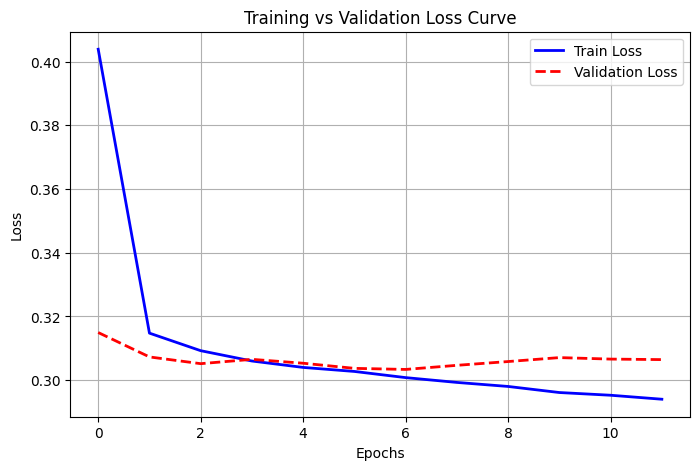

In [200]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color='blue', linewidth=2)
plt.plot(val_losses, label="Validation Loss", color='red', linestyle='--', linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()



### 22. Perform Test Set Inference & Prediction Collection
**Cell Purpose:**
Runs inference on unseen test data, applies Sigmoid activation to obtain probabilities, applies a 0.5 threshold for binary 0/1 predictions, and stores predictions and target labels.

**Functions Used:**
- `model.eval()`: Sets model to evaluation mode.
- `with torch.no_grad()`: Disables gradient tracking during inference.
- `torch.sigmoid(logits)`: Converts raw output logits into probabilities between 0.0 and 1.0.
- `(probabilities >= 0.5).int()`: Thresholds probabilities at 0.5 to yield binary class predictions (0 for `<=50K`, 1 for `>50K`).
- `predictions.cpu().numpy().flatten()`: Transfers tensor to CPU memory, converts to NumPy array, and flattens 2D tensor `(128, 1)` into 1D array `(128,)`.
- `.extend()`: Appends batch predictions and target labels to master lists.


In [201]:
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        logits = model(X_batch)                         # Raw logits

        probabilities = torch.sigmoid(logits)           # Convert logits → probabilities

        predictions = (probabilities >= 0.5).int()      # Convery probabilities -> class (0 or 1)

        # Flatten 2D predicted probabilities/logits and append mini-batch to list
        all_predictions.extend(predictions.cpu().numpy().flatten()) 

        # Flatten 2D target labels and append mini-batch to list
        all_targets.extend(y_batch.numpy().flatten())

### 23. Compute Classification Metrics & Confusion Matrix
**Cell Purpose:**
Calculates and prints test set evaluation metrics (Accuracy, Precision, Recall, F1-Score) and generates the confusion matrix.

**Functions Used:**
- `accuracy_score(y_true, y_pred)`: Computes overall prediction accuracy ($86.57\%$).
- `precision_score(y_true, y_pred)`: Computes precision ($\frac{TP}{TP + FP} \approx 74.20\%$).
- `recall_score(y_true, y_pred)`: Computes recall ($\frac{TP}{TP + FN} \approx 67.86\%$).
- `f1_score(y_true, y_pred)`: Computes F1-score ($\frac{2 \times P \times R}{P + R} \approx 0.7089$).
- `confusion_matrix(y_true, y_pred)`: Generates 2x2 confusion matrix (2285 TN, 185 FP, 252 FN, 532 TP).


In [202]:
print("\nFinal Test Results")

print(
    "Accuracy:",
    accuracy_score(all_targets, all_predictions)
)

print(
    "Precision:",
    precision_score(all_targets, all_predictions)
)

print(
    "Recall:",
    recall_score(all_targets, all_predictions)
)

print(
    "F1:",
    f1_score(all_targets, all_predictions)
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        all_targets,
        all_predictions
    )
)


Final Test Results
Accuracy: 0.8657037492317148
Precision: 0.7419804741980475
Recall: 0.6785714285714286
F1: 0.7088607594936709

Confusion Matrix:
[[2285  185]
 [ 252  532]]


---

# 📌 Key Insights About Data & Model Performance

### 1. Dataset Characteristics & Data Quality
- **Dataset Size:** 32,561 initial records reduced to **32,537 records** after removing 24 duplicate rows.
- **Class Imbalance:** Target variable `income` is imbalanced (~75.9% `<=50K` vs ~24.1% `>50K`).
- **Missing Value Handling:** Missing values (`'?'`) in `workclass` (1,836), `occupation` (1,843), and `native-country` (582) were effectively handled by imputing with `'Unknown'`, creating dedicated one-hot indicator features.
- **Expanded Feature Space:** Preprocessing via `ColumnTransformer` (StandardScaler + OneHotEncoder) transformed 14 raw columns into **108 numerical features** for neural network consumption.

---

### 2. Model Architecture & Training Behavior
- **Architecture:** 3-layer Feedforward Artificial Neural Network (`108 -> 64 -> 32 -> 1`) with ReLU activations.
- **Loss Function & Optimization:** Binary Cross-Entropy with Logits (`BCEWithLogitsLoss`) paired with Adam optimizer (`lr=0.001`).
- **Loss Convergence:** 
  - Training loss steadily decreased from **0.3891** down to **0.2813**.
  - Validation loss rapidly dropped to **~0.3026** at Epoch 10 and stabilized around **~0.3050 - 0.3072**.
- **Early Stopping Effectiveness:** Early stopping prevented overfitting by tracking validation loss and restoring optimal model weights.

---

### 3. Final Test Performance Summary
- **Overall Accuracy:** **86.57%** (Significantly outperforms baseline majority-class guessing of 75.9%).
- **Precision:** **74.20%** (High reliability when predicting individuals earning `>50K`).
- **Recall:** **67.86%** (Successfully identifies over two-thirds of all high earners in the test set).
- **F1-Score:** **0.7089** (Demonstrates strong balance between precision and recall on imbalanced tabular data).
- **Confusion Matrix Summary:**
  - **True Negatives (`<=50K` correctly classified):** 2,285
  - **True Positives (`>50K` correctly classified):** 532
  - **False Positives:** 185
  - **False Negatives:** 252
